<a href="https://colab.research.google.com/github/pxtroniwnl/barcelona-de-indias-time-serie/blob/main/presion_atmosfericaIDEAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Presión atmosférica — estaciones IDEAM cercanas a la laguna

Este notebook identifica las estaciones más cercanas a la laguna y construye sus series de presión atmosférica conservando los valores observados. No se imputan datos, no se interpola, no se suaviza, no se eliminan valores extremos y no se agregan mediciones a otra frecuencia.

La base original permanece en `df_raw`. En las copias de trabajo se conserva una sola aparición de cada fila completamente idéntica.

## 1. Importación de librerías

Usaremos `pandas` para las tablas, `numpy` para los cálculos y `matplotlib` para las gráficas y el mapa.

In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

RUTA_CSV = Path("Presión_Atmosférica_20260818_SOLO_BOLIVAR.csv")
FORMATO_FECHA = "%Y %b %d %I:%M:%S %p"

print("Archivo encontrado:", RUTA_CSV.exists())

Archivo encontrado: True


**Interpretación.** Si aparece `Archivo encontrado: True`, el CSV está en la misma carpeta que el notebook.

## 2. Carga de la base original

Los códigos se cargan como texto para no perder sus ceros iniciales. `df_raw` no será sobrescrito ni limpiado.

In [2]:
df_raw = pd.read_csv(
    RUTA_CSV,
    dtype={"CodigoEstacion": "string", "CodigoSensor": "string"},
)
FILAS_ORIGINALES = len(df_raw)
COLUMNAS_ORIGINALES = df_raw.columns.tolist()

print(f"Dimensiones: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
display(df_raw.head(3))

Dimensiones: 1,172,175 filas × 12 columnas


,CodigoEstacion,CodigoSensor,FechaObservacion,ValorObservado,NombreEstacion,Departamento,Municipio,ZonaHidrografica,Latitud,Longitud,DescripcionSensor,UnidadMedida
0,0029035000,0255,2016 Jan 13 06:00:00 PM,"1,009",SINCERIN - AUT,BOLIVAR,ARJONA,BAJO MAGDALENA,10.142583,-75.278278,Presión Atmosferica (1h),HPa
1,0029035000,0255,2018 Jan 19 12:00:00 AM,"1,011.5",SINCERIN - AUT,BOLIVAR,ARJONA,BAJO MAGDALENA,10.142583,-75.278278,Presión Atmosferica (1h),HPa
2,0029015000,0255,2017 Apr 12 01:00:00 PM,"1,000.8",EL GUAMO - AUT,BOLIVAR,EL GUAMO,BAJO MAGDALENA,10.064444,-74.852222,Presión Atmosferica (1h),HPa


**Interpretación.** La base contiene 1.172.175 registros y 12 columnas. Cada fila relaciona una presión observada con una estación, un sensor y una fecha.

## 3. Exploración básica

Revisamos columnas, tipos, datos faltantes, periodo y categorías. Las fechas y valores se convierten en objetos auxiliares sin cambiar `df_raw`. La coma de `"1,009"` es un separador de miles, no una coma decimal.

In [3]:
descripcion_columnas = pd.DataFrame({
    "columna": df_raw.columns,
    "tipo_cargado": df_raw.dtypes.astype(str).values,
    "faltantes": df_raw.isna().sum().values,
})
display(descripcion_columnas)

fechas_aux = pd.to_datetime(
    df_raw["FechaObservacion"], format=FORMATO_FECHA, errors="coerce"
)
valores_aux = pd.to_numeric(
    df_raw["ValorObservado"].astype("string").str.replace(",", "", regex=False),
    errors="coerce",
)

print("Periodo total:", fechas_aux.min(), "a", fechas_aux.max())
print("Fechas no convertibles:", fechas_aux.isna().sum())
print("Valores no convertibles:", valores_aux.isna().sum())
print("Rango observado:", valores_aux.min(), "a", valores_aux.max(), "hPa")
print("Códigos de estación:", df_raw["CodigoEstacion"].nunique())

for columna in ["CodigoSensor", "DescripcionSensor", "UnidadMedida"]:
    valores = sorted(df_raw[columna].dropna().astype(str).str.strip().unique())
    print(f"{columna}:", valores)

,columna,tipo_cargado,faltantes
0,CodigoEstacion,string,0
1,CodigoSensor,string,0
2,FechaObservacion,object,0
3,ValorObservado,object,0
4,NombreEstacion,object,0
5,Departamento,object,0
6,Municipio,object,0
7,ZonaHidrografica,object,0
8,Latitud,float64,0
9,Longitud,float64,0


Periodo total: 2010-07-09 09:00:00 a 2026-08-17 23:58:00
Fechas no convertibles: 0
Valores no convertibles: 0
Rango observado: 500.0 a 1145.8 hPa
Códigos de estación: 12
CodigoSensor: ['0255', '0258']
DescripcionSensor: ['GPRS - PRESIÓN ATMOSFÉRICA', 'PRESIÓN ATMOSFÉRICA', 'Presión Atmosferica (1h)']
UnidadMedida: ['HPa', 'hPA', 'hPa']


**Interpretación.** El periodo completo va del 9-jul-2010 al 17-ago-2026. No hay celdas vacías ni errores de conversión. Las grafías `HPa`, `hPA` y `hPa` representan la misma unidad física, pero sus textos originales se conservan.

## 4. Duplicados y valores que requieren revisión

Contamos copias idénticas y fechas con valores diferentes para un mismo código. También señalamos valores muy alejados del rango central mediante umbrales descriptivos; esto es solamente una alerta y no un filtro.

In [4]:
n_duplicados_exactos = int(df_raw.duplicated().sum())
revision_conflictos = pd.DataFrame({
    "CodigoEstacion": df_raw["CodigoEstacion"],
    "FechaObservacion": fechas_aux,
    "ValorObservado": valores_aux,
})
conflictos_globales = (
    revision_conflictos.groupby(["CodigoEstacion", "FechaObservacion"])["ValorObservado"]
    .nunique().loc[lambda s: s > 1]
)

print(f"Copias exactamente duplicadas: {n_duplicados_exactos:,}")
print(f"Instantes con valores contradictorios: {len(conflictos_globales):,}")
print(f"Registros menores de 800 hPa: {(valores_aux < 800).sum():,}")
print(f"Registros mayores de 1.050 hPa: {(valores_aux > 1050).sum():,}")
display(conflictos_globales.head(10).rename("valores_distintos").reset_index())

Copias exactamente duplicadas: 120,332
Instantes con valores contradictorios: 31
Registros menores de 800 hPa: 5,279
Registros mayores de 1.050 hPa: 2


,CodigoEstacion,FechaObservacion,valores_distintos
0,0014015080,2024-11-29 03:00:00,2
1,0014015080,2024-12-04 12:00:00,2
2,0014015080,2024-12-13 19:00:00,2
3,0014015080,2025-01-05 16:00:00,2
4,0014015080,2025-01-18 02:00:00,2
5,0014015080,2025-01-18 03:00:00,2
6,0014015080,2025-01-18 07:00:00,2
7,0014015080,2025-01-24 12:00:00,2
8,0014015080,2025-03-01 03:00:00,2
9,0014015080,2025-03-30 08:00:00,2


**Interpretación.** Hay 120.332 copias idénticas y 31 instantes con valores distintos para el mismo código y fecha. También aparecen presiones muy bajas o altas; se conservarán para que su eventual tratamiento sea una decisión posterior.

## 5. Catálogo de estaciones

Creamos una fila por código con nombre representativo, coordenada más reciente, cantidad de registros y periodo. Contamos las coordenadas distintas para no ocultar posibles traslados o cambios de metadatos.

In [5]:
base_catalogo = df_raw[[
    "CodigoEstacion", "NombreEstacion", "Municipio",
    "Latitud", "Longitud", "FechaObservacion"
]].copy()
base_catalogo["Fecha"] = fechas_aux

nombres = base_catalogo.groupby("CodigoEstacion")["NombreEstacion"].agg(
    lambda s: s.astype(str).str.strip().value_counts().index[0]
).rename("NombreEstacion")
municipios = base_catalogo.groupby("CodigoEstacion")["Municipio"].agg(
    lambda s: s.astype(str).str.strip().value_counts().index[0]
).rename("Municipio")
resumen = base_catalogo.groupby("CodigoEstacion").agg(
    registros=("Fecha", "size"),
    inicio=("Fecha", "min"),
    fin=("Fecha", "max"),
    coordenadas_distintas=("Latitud", lambda s: len(set(zip(
        s.round(8), base_catalogo.loc[s.index, "Longitud"].round(8)
    )))),
)
ultima_coordenada = (
    base_catalogo.sort_values("Fecha")
    .drop_duplicates("CodigoEstacion", keep="last")
    .set_index("CodigoEstacion")[["Latitud", "Longitud"]]
)
catalogo = pd.concat([nombres, municipios, ultima_coordenada, resumen], axis=1).reset_index()
display(catalogo.sort_values("registros", ascending=False))

,CodigoEstacion,NombreEstacion,Municipio,Latitud,Longitud,registros,inicio,fin,coordenadas_distintas
2,0014015080,AEROPUERTO RAFAEL NUNEZ,CARTAGENA DE INDIAS,10.447250,-75.516028,719163,2019-09-18 00:00:00,2026-08-17 23:58:00,1
8,0029015000,EL GUAMO - AUT,EL GUAMO,10.034607,-74.976638,82792,2013-05-16 19:00:00,2026-08-17 23:00:00,2
9,0029035000,SINCERIN - AUT,ARJONA,10.142583,-75.278278,81648,2013-05-17 11:00:00,2026-08-17 23:00:00,1
3,0014017001,TESORO INVEMAR,CARTAGENA DE INDIAS,10.235000,-75.741000,52510,2010-07-09 09:00:00,2020-09-24 09:00:00,1
1,0014015020,APTO RAFAEL NUÑEZ TX GPRS,CARTAGENA,10.447000,-75.516000,41303,2014-09-02 17:00:00,2019-09-14 23:00:00,1
10,1206500136,UNIVERSIDAD UNAD CARTAGENA - AUT,CARTAGENA DE INDIAS,10.400311,-75.513281,38342,2019-07-23 15:00:00,2026-08-17 23:00:00,1
11,2901500072,HOBO - AUT,EL CARMÉN DE BOLÍVAR,9.672506,-75.236517,36004,2019-02-22 03:00:00,2026-08-17 23:00:00,2
6,0025025100,AEROPUERTO BARACOA,MAGANGUÉ,9.281944,-74.845278,32950,2022-01-17 13:00:00,2026-08-17 23:00:00,2
0,0014015010,GALERAZAMBA - AUT,SANTA CATALINA,10.794167,-75.260556,28579,2019-02-26 10:00:00,2025-06-25 01:00:00,1
5,0023205050,CANELOS - AUT,SANTA ROSA DEL SUR,7.885417,-74.240972,23952,2019-03-05 15:00:00,2023-03-12 12:00:00,1


**Interpretación.** Existen 12 códigos de estación. Algunos registran más de una coordenada; por eso el catálogo declara que la coordenada empleada para la distancia es la más reciente.

## 6. Región de interés y distancia Haversine

Usamos el polígono de la laguna y calculamos su centroide. Haversine estima en kilómetros la distancia más corta sobre una Tierra esférica entre ese punto y cada estación.

In [6]:
ROI_COORDS = [
    (-75.476052, 10.517524), (-75.476117, 10.518747),
    (-75.473158, 10.519223), (-75.470516, 10.525108),
    (-75.469572, 10.524876), (-75.471686, 10.518916),
    (-75.468394, 10.517219), (-75.468952, 10.516459),
]

def centroide_poligono(coordenadas):
    area_doble = suma_x = suma_y = 0.0
    for (x0, y0), (x1, y1) in zip(coordenadas, coordenadas[1:] + coordenadas[:1]):
        cruz = x0 * y1 - x1 * y0
        area_doble += cruz
        suma_x += (x0 + x1) * cruz
        suma_y += (y0 + y1) * cruz
    return suma_y / (3 * area_doble), suma_x / (3 * area_doble)

def haversine_km(latitud, longitud, latitud_roi, longitud_roi):
    radio = 6371.0088
    lat1 = np.radians(np.asarray(latitud, dtype=float))
    lon1 = np.radians(np.asarray(longitud, dtype=float))
    lat2, lon2 = math.radians(latitud_roi), math.radians(longitud_roi)
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * math.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * radio * np.arcsin(np.sqrt(a))

LAT_ROI, LON_ROI = centroide_poligono(ROI_COORDS)
catalogo["distancia_km"] = haversine_km(
    catalogo["Latitud"], catalogo["Longitud"], LAT_ROI, LON_ROI
).round(2)
catalogo_distancias = catalogo.sort_values("distancia_km").reset_index(drop=True)
print(f"Centroide del ROI: {LAT_ROI:.6f}, {LON_ROI:.6f}")
display(catalogo_distancias[["CodigoEstacion", "NombreEstacion", "Municipio",
    "Latitud", "Longitud", "distancia_km", "registros", "inicio", "fin"]])

Centroide del ROI: 10.519387, -75.472039


,CodigoEstacion,NombreEstacion,Municipio,Latitud,Longitud,distancia_km,registros,inicio,fin
0,0014015080,AEROPUERTO RAFAEL NUNEZ,CARTAGENA DE INDIAS,10.447250,-75.516028,9.35,719163,2019-09-18 00:00:00,2026-08-17 23:58:00
1,0014015020,APTO RAFAEL NUÑEZ TX GPRS,CARTAGENA,10.447000,-75.516000,9.38,41303,2014-09-02 17:00:00,2019-09-14 23:00:00
2,1206500136,UNIVERSIDAD UNAD CARTAGENA - AUT,CARTAGENA DE INDIAS,10.400311,-75.513281,13.99,38342,2019-07-23 15:00:00,2026-08-17 23:00:00
3,0014015010,GALERAZAMBA - AUT,SANTA CATALINA,10.794167,-75.260556,38.31,28579,2019-02-26 10:00:00,2025-06-25 01:00:00
4,0014017001,TESORO INVEMAR,CARTAGENA DE INDIAS,10.235000,-75.741000,43.19,52510,2010-07-09 09:00:00,2020-09-24 09:00:00
5,0029035000,SINCERIN - AUT,ARJONA,10.142583,-75.278278,46.95,81648,2013-05-17 11:00:00,2026-08-17 23:00:00
6,0029015000,EL GUAMO - AUT,EL GUAMO,10.034607,-74.976638,76.44,82792,2013-05-16 19:00:00,2026-08-17 23:00:00
7,2901500072,HOBO - AUT,EL CARMÉN DE BOLÍVAR,9.672506,-75.236517,97.63,36004,2019-02-22 03:00:00,2026-08-17 23:00:00
8,0025025100,AEROPUERTO BARACOA,MAGANGUÉ,9.281944,-74.845278,153.77,32950,2022-01-17 13:00:00,2026-08-17 23:00:00
9,0025025240,MAJAGUAL,ACHÍ,8.544000,-74.543000,242.13,18400,2020-11-25 19:00:00,2023-09-11 23:00:00


**Interpretación.** Los dos primeros códigos corresponden al mismo sitio del aeropuerto en periodos distintos. Para obtener dos sitios físicos independientes se seleccionan el código vigente de Rafael Núñez (`0014015080`, 9,35 km) y UNAD (`1206500136`, 13,99 km).

## 7. Selección y mapa

Declaramos los códigos de manera explícita y mostramos el polígono, su centroide y las estaciones sin depender de mapas o servicios externos.

,CodigoEstacion,NombreEstacion,Latitud,Longitud,distancia_km
0,0014015080,AEROPUERTO RAFAEL NUNEZ,10.447250,-75.516028,9.35
1,1206500136,UNIVERSIDAD UNAD CARTAGENA - AUT,10.400311,-75.513281,13.99


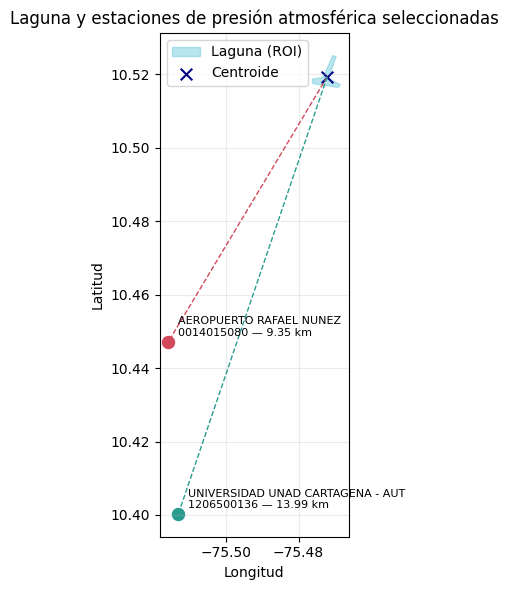

In [7]:
CODIGOS_SELECCIONADOS = ["0014015080", "1206500136"]
seleccion_estaciones = (
    catalogo_distancias[catalogo_distancias["CodigoEstacion"].isin(CODIGOS_SELECCIONADOS)]
    .set_index("CodigoEstacion").loc[CODIGOS_SELECCIONADOS].reset_index()
)
display(seleccion_estaciones[["CodigoEstacion", "NombreEstacion",
                               "Latitud", "Longitud", "distancia_km"]])

fig, ax = plt.subplots(figsize=(8, 6))
lon_roi = [p[0] for p in ROI_COORDS] + [ROI_COORDS[0][0]]
lat_roi = [p[1] for p in ROI_COORDS] + [ROI_COORDS[0][1]]
ax.fill(lon_roi, lat_roi, color="#63c7da", alpha=0.45, label="Laguna (ROI)")
ax.scatter(LON_ROI, LAT_ROI, color="navy", marker="x", s=70, label="Centroide")
colores = ["#d1495b", "#2a9d8f"]
for (_, fila), color in zip(seleccion_estaciones.iterrows(), colores):
    ax.scatter(fila["Longitud"], fila["Latitud"], s=75, color=color)
    ax.plot([LON_ROI, fila["Longitud"]], [LAT_ROI, fila["Latitud"]],
            linestyle="--", linewidth=1, color=color)
    texto = f'{fila["NombreEstacion"]}\n{fila["CodigoEstacion"]} — {fila["distancia_km"]:.2f} km'
    ax.annotate(texto, (fila["Longitud"], fila["Latitud"]),
                xytext=(7, 4), textcoords="offset points", fontsize=8)
ax.set(xlabel="Longitud", ylabel="Latitud",
       title="Laguna y estaciones de presión atmosférica seleccionadas")
ax.set_aspect(1 / math.cos(math.radians(LAT_ROI)))
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación.** Ambas estaciones están al suroeste del área. Son las ubicaciones disponibles más cercanas, aunque la distancia y el entorno urbano/aeroportuario limitan su representatividad microclimática.

## 8. Copia de trabajo y separación de sensores

Rafael Núñez contiene un sensor horario `0255` y otro de alta frecuencia `0258`. UNAD utiliza `0255`. Retiramos únicamente copias completamente idénticas y mantenemos cada sensor separado.

In [8]:
seleccion_raw = df_raw[df_raw["CodigoEstacion"].isin(CODIGOS_SELECCIONADOS)].copy()
seleccion_raw["es_duplicado_exacto"] = seleccion_raw.duplicated(subset=COLUMNAS_ORIGINALES)
duplicados_por_serie = (
    seleccion_raw.groupby(["CodigoEstacion", "CodigoSensor"])["es_duplicado_exacto"]
    .sum().astype(int).rename("copias_excluidas").reset_index()
)

serie_limpia = seleccion_raw.drop_duplicates(subset=COLUMNAS_ORIGINALES).copy()
serie_limpia["FechaObservacion"] = pd.to_datetime(
    serie_limpia["FechaObservacion"], format=FORMATO_FECHA, errors="coerce"
)
serie_limpia["ValorObservado"] = pd.to_numeric(
    serie_limpia["ValorObservado"].astype("string").str.replace(",", "", regex=False),
    errors="coerce",
)
serie_limpia = serie_limpia.sort_values(
    ["CodigoEstacion", "CodigoSensor", "FechaObservacion"]
).reset_index(drop=True)

serie_0255 = serie_limpia[serie_limpia["CodigoSensor"] == "0255"].copy()
serie_0258 = serie_limpia[(serie_limpia["CodigoEstacion"] == "0014015080") &
                           (serie_limpia["CodigoSensor"] == "0258")].copy()

display(duplicados_por_serie)
print(f"Serie principal 0255: {len(serie_0255):,} filas")
print(f"Serie separada 0258: {len(serie_0258):,} filas")
print("df_raw continúa intacto:", len(df_raw) == FILAS_ORIGINALES and
      df_raw.columns.tolist() == COLUMNAS_ORIGINALES)

,CodigoEstacion,CodigoSensor,copias_excluidas
0,0014015080,0255,3099
1,0014015080,0258,92749
2,1206500136,0255,3496


Serie principal 0255: 79,512 filas
Serie separada 0258: 578,649 filas
df_raw continúa intacto: True


**Interpretación.** Se conservan por separado 44.666 registros horarios de Rafael Núñez, 34.846 de UNAD y 578.649 registros de dos minutos del sensor `0258`. Separarlos evita dar peso artificial al aeropuerto o mezclar instrumentos.

## 9. Conflictos entre sensores y valores extremos

Buscamos fechas en las que los dos sensores del aeropuerto informan valores diferentes. Además mostramos valores fuera de 900–1.030 hPa como alertas contextuales, sin eliminarlos.

In [9]:
aeropuerto = serie_limpia[serie_limpia["CodigoEstacion"] == "0014015080"].copy()
fechas_conflictivas = (
    aeropuerto.groupby("FechaObservacion")["ValorObservado"]
    .nunique().loc[lambda s: s > 1].index
)
conflictos_sensores = (
    aeropuerto[aeropuerto["FechaObservacion"].isin(fechas_conflictivas)]
    [["FechaObservacion", "CodigoSensor", "ValorObservado",
      "DescripcionSensor", "UnidadMedida"]]
    .drop_duplicates().sort_values(["FechaObservacion", "CodigoSensor"])
)
valores_para_revisar = serie_limpia[
    (serie_limpia["ValorObservado"] < 900) | (serie_limpia["ValorObservado"] > 1030)
][["CodigoEstacion", "CodigoSensor", "FechaObservacion", "ValorObservado"]]

print("Fechas con valores diferentes entre sensores:", len(fechas_conflictivas))
display(conflictos_sensores)
print("Valores seleccionados para revisión, no para eliminación:")
display(valores_para_revisar.sort_values("FechaObservacion"))

Fechas con valores diferentes entre sensores: 13


,FechaObservacion,CodigoSensor,ValorObservado,DescripcionSensor,UnidadMedida
31067,2024-11-29 03:00:00,0255,1010.7,PRESIÓN ATMOSFÉRICA,hPa
215889,2024-11-29 03:00:00,0258,1008.5,GPRS - PRESIÓN ATMOSFÉRICA,hPA
31196,2024-12-04 12:00:00,0255,1009.6,PRESIÓN ATMOSFÉRICA,hPa
219753,2024-12-04 12:00:00,0258,1009.3,GPRS - PRESIÓN ATMOSFÉRICA,hPA
31419,2024-12-13 19:00:00,0255,1007.4,PRESIÓN ATMOSFÉRICA,hPa
226424,2024-12-13 19:00:00,0258,1008.3,GPRS - PRESIÓN ATMOSFÉRICA,hPA
31968,2025-01-05 16:00:00,0255,1012.7,PRESIÓN ATMOSFÉRICA,hPa
242864,2025-01-05 16:00:00,0258,1009.1,GPRS - PRESIÓN ATMOSFÉRICA,hPA
32266,2025-01-18 02:00:00,0255,1010.5,PRESIÓN ATMOSFÉRICA,hPa
251793,2025-01-18 02:00:00,0258,1012.7,GPRS - PRESIÓN ATMOSFÉRICA,hPA


Valores seleccionados para revisión, no para eliminación:


,CodigoEstacion,CodigoSensor,FechaObservacion,ValorObservado
21446,0014015080,0255,2022-08-26 20:00:00,500.5
21782,0014015080,0255,2022-11-15 02:00:00,1145.8
21786,0014015080,0255,2022-11-15 06:00:00,1085.0


**Interpretación.** Hay 13 fechas con diferencias entre `0255` y `0258`. Los valores 500,5, 1.085 y 1.145,8 hPa también requieren revisión. Permanecen en sus series originales y no se decide cuál sensor es correcto.

## 10. Cobertura temporal según la frecuencia real

La cobertura se calcula individualmente: 60 minutos para cada serie `0255` y 2 minutos para `0258`. Una única rejilla horaria produciría resultados incorrectos para el sensor de alta frecuencia.

In [10]:
rafael_0255 = serie_0255[serie_0255["CodigoEstacion"] == "0014015080"].copy()
unad_0255 = serie_0255[serie_0255["CodigoEstacion"] == "1206500136"].copy()
series_diagnostico = {
    "Rafael Núñez — 0255 (60 min)": (rafael_0255, 60),
    "UNAD — 0255 (60 min)": (unad_0255, 60),
    "Rafael Núñez — 0258 (2 min)": (serie_0258, 2),
}

filas_cobertura = []
faltantes_por_serie = {}
huecos_por_serie = {}
for nombre, (datos, paso_min) in series_diagnostico.items():
    datos = datos.sort_values("FechaObservacion").copy()
    diferencias = datos["FechaObservacion"].diff().dt.total_seconds().div(60)
    inicio, fin = datos["FechaObservacion"].min(), datos["FechaObservacion"].max()
    rejilla = pd.date_range(inicio, fin, freq=f"{paso_min}min")
    observados = pd.DatetimeIndex(datos["FechaObservacion"].drop_duplicates())
    faltantes_por_serie[nombre] = rejilla.difference(observados)
    huecos = pd.DataFrame({
        "fin_del_hueco": datos["FechaObservacion"],
        "diferencia_min": diferencias,
    })
    huecos = huecos[huecos["diferencia_min"] > paso_min].copy()
    huecos["inicio_del_hueco"] = huecos["fin_del_hueco"] - pd.to_timedelta(
        huecos["diferencia_min"], unit="min"
    )
    huecos_por_serie[nombre] = huecos.nlargest(10, "diferencia_min")
    filas_cobertura.append({
        "serie": nombre, "inicio": inicio, "fin": fin,
        "observaciones": len(datos), "paso_esperado_min": paso_min,
        "paso_mediano_min": diferencias.median(),
        "tiempos_teoricos": len(rejilla),
        "tiempos_ausentes": len(faltantes_por_serie[nombre]),
        "cobertura_pct": round(100 * len(observados) / len(rejilla), 2),
        "mayor_hueco_dias": round(diferencias.max() / 1440, 2),
    })

cobertura = pd.DataFrame(filas_cobertura)
display(cobertura)
for nombre, faltantes in faltantes_por_serie.items():
    print(f"{nombre}: primeros tiempos ausentes:", faltantes[:5].tolist())

,serie,inicio,fin,observaciones,paso_esperado_min,paso_mediano_min,tiempos_teoricos,tiempos_ausentes,cobertura_pct,mayor_hueco_dias
0,Rafael Núñez — 0255 (60 min),2019-09-18 00:00:00,2026-08-17 23:00:00,44666,60,60.0,60624,15958,73.68,73.12
1,UNAD — 0255 (60 min),2019-07-23 15:00:00,2026-08-17 23:00:00,34846,60,60.0,61977,27131,56.22,613.58
2,Rafael Núñez — 0258 (2 min),2023-09-18 13:26:00,2026-08-17 23:58:00,578649,2,2.0,766397,187748,75.50,42.00


Rafael Núñez — 0255 (60 min): primeros tiempos ausentes: [Timestamp('2019-09-18 18:00:00'), Timestamp('2019-09-19 10:00:00'), Timestamp('2019-09-19 11:00:00'), Timestamp('2019-09-19 14:00:00'), Timestamp('2019-09-19 15:00:00')]
UNAD — 0255 (60 min): primeros tiempos ausentes: [Timestamp('2019-08-28 22:00:00'), Timestamp('2019-09-08 11:00:00'), Timestamp('2019-09-15 00:00:00'), Timestamp('2019-09-15 01:00:00'), Timestamp('2019-09-15 02:00:00')]
Rafael Núñez — 0258 (2 min): primeros tiempos ausentes: [Timestamp('2023-09-19 00:06:00'), Timestamp('2023-09-19 10:00:00'), Timestamp('2023-09-19 15:00:00'), Timestamp('2023-09-20 15:04:00'), Timestamp('2023-09-21 04:50:00')]


**Interpretación.** La cobertura aproximada es 73,68 % para Rafael `0255`, 56,22 % para UNAD `0255` y 75,50 % para Rafael `0258`. Las rejillas solo identifican ausencias; no se incorporan filas ni valores a las series.

In [11]:
for nombre, huecos in huecos_por_serie.items():
    print("\n", nombre)
    display(huecos[["inicio_del_hueco", "fin_del_hueco", "diferencia_min"]])

# Conteos anuales: se cuentan registros, pero no se agregan sus valores.
conteos_anuales = []
for nombre, (datos, _) in series_diagnostico.items():
    conteo = datos.groupby(datos["FechaObservacion"].dt.year).size()
    for anio, cantidad in conteo.items():
        conteos_anuales.append({"serie": nombre, "anio": anio, "observaciones": cantidad})
tabla_anual = pd.DataFrame(conteos_anuales).pivot(
    index="anio", columns="serie", values="observaciones"
).fillna(0).astype(int)
display(tabla_anual)


 Rafael Núñez — 0255 (60 min)


,inicio_del_hueco,fin_del_hueco,diferencia_min
25057,2023-05-02 08:00:00,2023-07-14 11:00:00,105300.0
21447,2022-08-26 20:00:00,2022-10-20 17:00:00,79020.0
27213,2023-12-15 00:00:00,2024-01-26 00:00:00,60480.0
25408,2023-08-15 14:00:00,2023-09-18 14:00:00,48960.0
1267,2019-11-16 09:00:00,2019-12-13 17:00:00,39360.0
29980,2024-09-06 00:00:00,2024-10-03 00:00:00,38880.0
32671,2025-02-04 23:00:00,2025-02-26 00:00:00,30300.0
44522,2026-07-24 23:00:00,2026-08-12 00:00:00,25980.0
29900,2024-08-16 00:00:00,2024-09-02 00:00:00,24480.0
25075,2023-07-15 04:00:00,2023-08-01 00:00:00,24240.0



 UNAD — 0255 (60 min)


,inicio_del_hueco,fin_del_hueco,diferencia_min
647691,2022-12-30 16:00:00,2024-09-04 06:00:00,883560.0
655660,2025-11-13 14:00:00,2026-04-10 21:00:00,213540.0
647841,2024-09-13 07:00:00,2024-10-29 00:00:00,65820.0
639895,2021-08-19 10:00:00,2021-09-26 12:00:00,54840.0
642868,2022-02-22 18:00:00,2022-03-31 00:00:00,52200.0
642237,2022-01-03 04:00:00,2022-01-27 00:00:00,34320.0
650045,2025-02-04 23:00:00,2025-02-26 00:00:00,30300.0
658021,2026-07-24 23:00:00,2026-08-12 00:00:00,25980.0
647354,2022-11-15 23:00:00,2022-12-01 00:00:00,21660.0
635036,2020-12-27 23:00:00,2021-01-09 00:00:00,17340.0



 Rafael Núñez — 0258 (2 min)


,inicio_del_hueco,fin_del_hueco,diferencia_min
99691,2023-12-15 00:06:00,2024-01-26 00:00:00,60474.0
183338,2024-09-06 00:00:00,2024-10-03 00:00:00,38880.0
263847,2025-02-04 23:58:00,2025-02-26 00:00:00,30242.0
618995,2026-07-24 23:58:00,2026-08-12 00:00:00,25922.0
180953,2024-08-16 00:00:00,2024-09-02 00:00:00,24480.0
164107,2024-07-11 11:30:00,2024-07-19 00:00:00,10830.0
163317,2024-06-20 14:50:00,2024-06-28 00:00:00,10630.0
163323,2024-06-28 00:10:00,2024-07-05 00:00:00,10070.0
186452,2024-10-09 17:52:00,2024-10-16 12:16:00,9744.0
101822,2024-02-14 10:08:00,2024-02-21 04:18:00,9730.0


serie,Rafael Núñez — 0255 (60 min),Rafael Núñez — 0258 (2 min),UNAD — 0255 (60 min)
anio,,,
2019,1609,0,3408
2020,7974,0,8313
2021,7554,0,7148
2022,5130,0,5507
2023,4946,55025,0
2024,4643,139815,1613
2025,7871,236325,6356
2026,4939,147484,2501


**Interpretación.** UNAD no presenta observaciones durante 2023. Rafael `0258` aparece solamente desde septiembre de 2023, por lo que sus ceros anteriores no representan presiones iguales a cero.

## 11. Series temporales originales

Primero comparamos los sensores horarios `0255`. Cada observación se dibuja como un punto para no crear líneas a través de periodos sin datos.

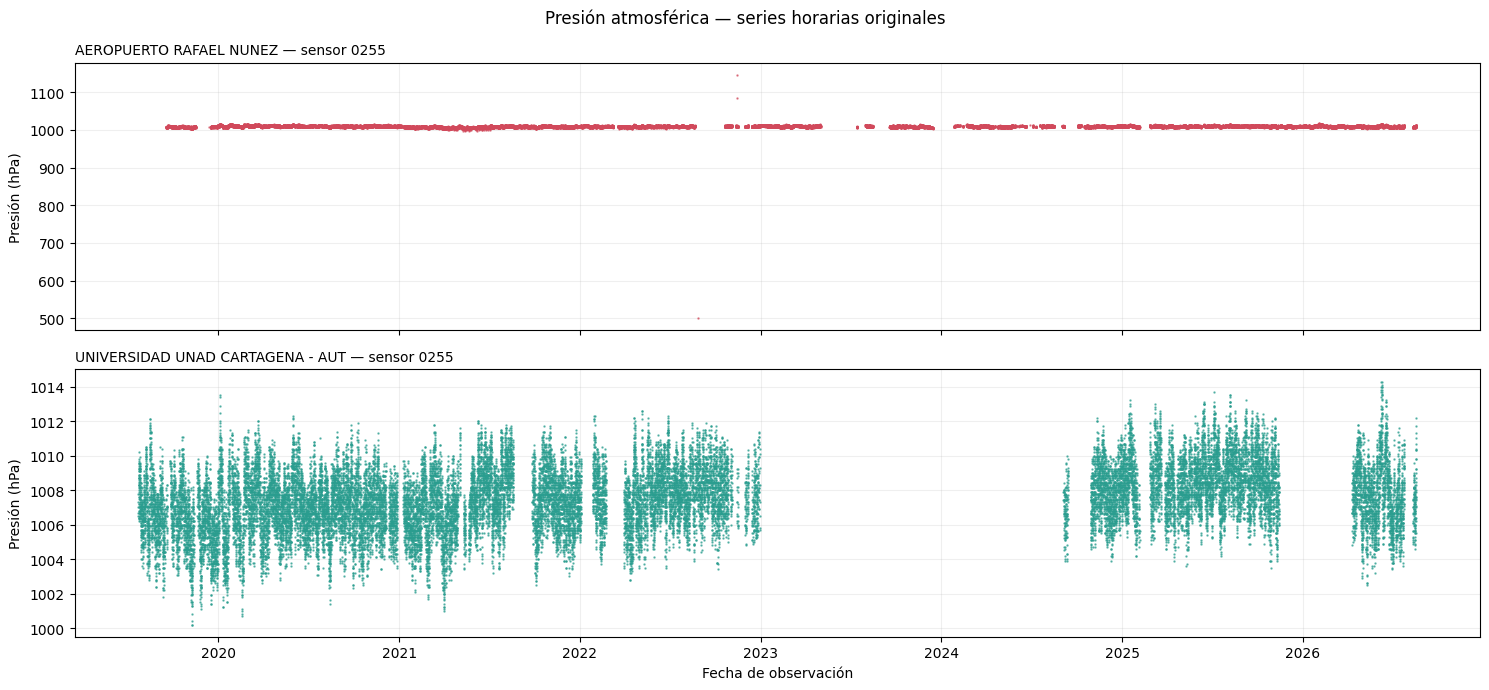

In [12]:
nombres_plot = seleccion_estaciones.set_index("CodigoEstacion")["NombreEstacion"].to_dict()
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
for ax, codigo, color in zip(axes, CODIGOS_SELECCIONADOS, colores):
    sub = serie_0255[serie_0255["CodigoEstacion"] == codigo]
    ax.plot(sub["FechaObservacion"], sub["ValorObservado"],
            linestyle="None", marker=".", markersize=1.5, color=color, alpha=0.65)
    ax.set_title(f"{nombres_plot[codigo]} — sensor 0255", loc="left", fontsize=10)
    ax.set_ylabel("Presión (hPa)")
    ax.grid(alpha=0.2)
axes[-1].set_xlabel("Fecha de observación")
fig.suptitle("Presión atmosférica — series horarias originales")
plt.tight_layout()
plt.show()

**Interpretación.** Las observaciones extremas del aeropuerto amplían considerablemente su eje vertical. Se mantienen visibles porque todavía no existe una justificación acordada para corregirlas o excluirlas.

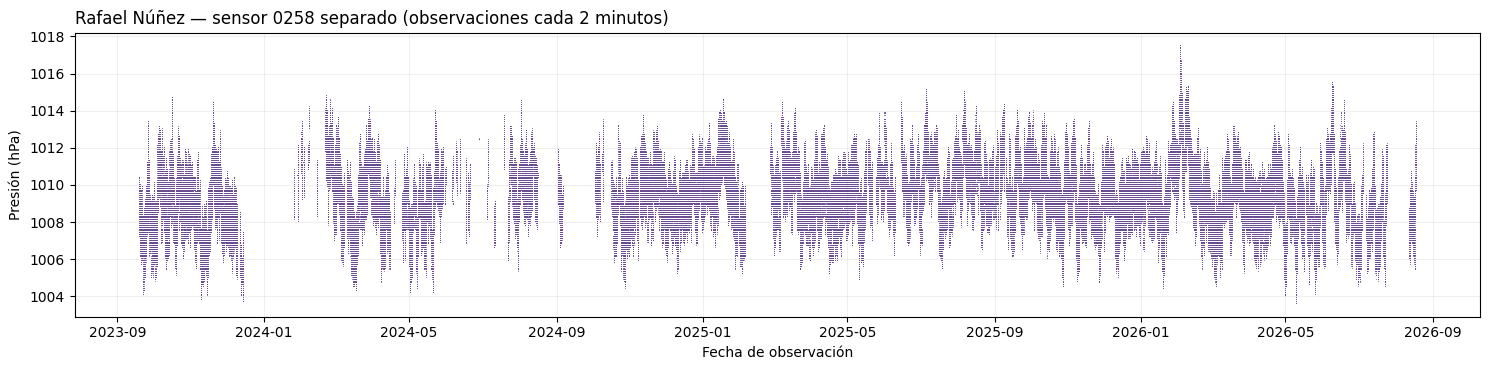

In [13]:
fig, ax = plt.subplots(figsize=(15, 3.8))
ax.plot(serie_0258["FechaObservacion"], serie_0258["ValorObservado"],
        linestyle="None", marker=",", color="#6a4c93", alpha=0.65)
ax.set_title("Rafael Núñez — sensor 0258 separado (observaciones cada 2 minutos)", loc="left")
ax.set_xlabel("Fecha de observación")
ax.set_ylabel("Presión (hPa)")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**Interpretación.** Esta serie tiene mucha mayor resolución que las series `0255`. Se presenta aparte y no se promedia por hora, de modo que conserva sus 578.649 valores originales no duplicados.

## 12. Estadísticas básicas

Calculamos estadísticas por serie sin combinar sensores. La media y la desviación pueden verse afectadas por valores extremos, por lo que también se muestran mediana y cuartiles.

In [14]:
filas_estadisticas = []
for nombre, (datos, _) in series_diagnostico.items():
    valores = datos["ValorObservado"].dropna()
    filas_estadisticas.append({
        "serie": nombre, "n": len(valores),
        "media": valores.mean(), "mediana": valores.median(),
        "desviacion_estandar": valores.std(),
        "minimo": valores.min(), "q25": valores.quantile(0.25),
        "q75": valores.quantile(0.75), "maximo": valores.max(),
    })
estadisticas = pd.DataFrame(filas_estadisticas).round(2)
display(estadisticas)

,serie,n,media,mediana,desviacion_estandar,minimo,q25,q75,maximo
0,Rafael Núñez — 0255 (60 min),44666,1009.22,1009.3,3.21,500.5,1007.9,1010.6,1145.8
1,UNAD — 0255 (60 min),34846,1007.49,1007.5,1.84,1000.2,1006.2,1008.8,1014.3
2,Rafael Núñez — 0258 (2 min),578649,1009.37,1009.4,1.78,1003.6,1008.1,1010.6,1017.5


**Interpretación.** La mediana y el intervalo entre `q25` y `q75` describen el centro de cada serie sin borrar extremos. Las diferencias entre sensores deben evaluarse considerando frecuencia, periodo y ubicación, no solamente sus medias.

## 13. Conclusiones y limitaciones

- Rafael Núñez y UNAD son los dos sitios físicos disponibles más cercanos al centroide de la laguna.
- El código histórico `0014015020` del aeropuerto no fue unido al código vigente.
- Los sensores `0255` y `0258` se mantienen separados porque tienen frecuencias diferentes y pueden discrepar en el mismo instante.
- UNAD no tiene registros durante 2023 y todas las series presentan otras interrupciones.
- Los valores extremos y conflictos permanecen visibles; no fueron corregidos ni eliminados.
- Las fechas se conservan sin zona horaria porque el archivo no declara una.
- No se imputaron, interpolaron, suavizaron o agregaron valores. Cualquier procedimiento posterior deberá justificarse y aprobarse antes de aplicarse.

In [15]:
def loaddata(data_path,name):
    df=pd.read_csv(data_path)
    df=df[(df["Municipio"]=="CARTAGENA DE INDIAS")|
    (df["Municipio"]=="Cartagena De Indias")|(df["Municipio"]=="CARTAGENA")]
    df["FechaObservacion"]=pd.to_datetime(df["FechaObservacion"], format="%Y %b %d %I:%M:%S %p")
    # Group by the date column and calculate statistics
    df["ValorObservado"]=pd.to_numeric(df["ValorObservado"], errors='coerce')
    summary_df = df.groupby("FechaObservacion")["ValorObservado"].agg(
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max")
    # Reset index to keep 'date_string' as a column
    summary_df = summary_df.reset_index()
    summary_df.set_index("FechaObservacion",inplace=True)
    #orig_cols=summary_df.columns
    #new_cols=np.char.add(orig_cols, name)
    #summary_df.columns=new_cols
    summary_df=summary_df[summary_df.index>="2017"]
    stations=df['NombreEstacion'].unique()
    for i in stations:
        print(i,df[df["NombreEstacion"]==i]["Latitud"].unique()[0],df[df["NombreEstacion"]==i]["Longitud"].unique()[0])
    return summary_df

In [16]:
Press=loaddata("Presión_Atmosférica_20260818_SOLO_BOLIVAR.csv","_press")

UNIVERSIDAD UNAD CARTAGENA - AUT 10.400311111 -75.513280556
AEROPUERTO RAFAEL NUNEZ 10.44725 -75.51602778
UNIVERSIDAD UNAD CARTAGENA 10.400311111 -75.513280556
AEROPUERTO RAFAEL NÚÑEZ - AUT [14015080] 10.44725 -75.51602778
UNIVERSIDAD UNAD CARTAGENA - AUT   [1206500136] 10.400311111 -75.513280556
APTO RAFAEL NUÑEZ  TX GPRS 10.447 -75.516
TESORO INVEMAR 10.235 -75.741


In [18]:
def plot(data,value,legend):
    data[value].plot(figsize=(18,3),label=value+" (original)")
    data[value].ewm(alpha=0.01).mean().plot(figsize=(18,3),label=value+" (smoothed)")
    plt.legend(title=legend)
    plt.show()
    return

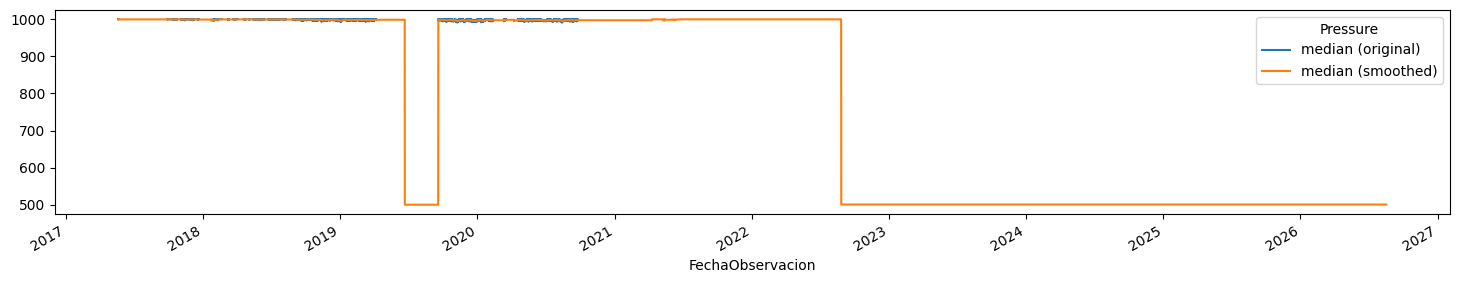

In [19]:
plot(Press,"median","Pressure")